<a href="https://colab.research.google.com/github/TheraMind-Project-Team/Psychologist-Project-AI/blob/main/PrePocessing_Audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import os
import glob
import numpy as np
from google.colab import drive
import warnings
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [ ]:
import requests
import os
file_url="https://dcapswoz.ict.usc.edu/wwwdaicwoz/419_P.zip"
file_drive="/content/drive/MyDrive/data.zip"
file_extract="/content/drive/MyDrive/drive_exract"
try:
  r=requests.get(file_url,stream=True)
except exceptions as e:
  print(e)
if r.status_code == 200:
    with open(file_drive, "wb") as f:
      for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)


!unzip -q "$file_drive" -d "$file_extract"

In [ ]:
drive_path="/content/drive/MyDrive"
drive_data="drive_exract"
drive_data_path=os.path.join(drive_path,drive_data)
drive_train_path=os.path.join(drive_data_path,"train_split_Depression_AVEC2017.csv")
def summeruzie(df):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore",category=RuntimeWarning)
    stats = df.agg(['mean', 'std', 'min', 'max']).transpose()
    summerzie_file=stats.unstack().to_frame().T
    summerzie_file.columns = [f"{col}_{stat}" for col, stat in summerzie_file.columns]
  return summerzie_file
all_audio_smmerize=[]
formant = glob.glob(f"{drive_data_path}/*_FORMANT.csv")
for fpath in formant:
    id=os.path.basename(fpath).split("_")[0]
    p_id=int(id)
    participant_summary = {'participant_id': p_id}
    df_formant= pd.read_csv(fpath)
    df_formant.columns = {f"F{i+1}" for i in range(df_formant.shape[1])}
    formant_summary=summeruzie(df_formant)
    participant_summary.update(formant_summary.to_dict('records')[0])
    covarep_path = os.path.join(drive_data_path, f"{id}_COVAREP.csv")
    df_covarep = pd.read_csv(covarep_path)
    df_covarep_subset = df_covarep.iloc[:, :10]
    df_covarep_subset.columns = [f'C{i+1}' for i in range(df_covarep_subset.shape[1])]
    covarep_summary = summeruzie(df_covarep_subset)
    participant_summary.update(covarep_summary.to_dict('records')[0])
    all_audio_smmerize.append(participant_summary)
    df_audio = pd.DataFrame(all_audio_smmerize)
df_audio



# New Section

In [ ]:
audio1="/content/drive/MyDrive/AUDIO_READY_TEAST"
df_audio.to_csv(audio1, index=False, encoding='utf-8')

NameError: name 'df_audio' is not defined

In [ ]:
pd.read_csv("/content/drive/MyDrive/AUDIO_READY_TEAST")

In [ ]:


df_labels = pd.read_csv(drive_train_path)
df_labels.rename(columns={'Participant_ID': 'participant_id'}, inplace=True)
df_final_training = pd.merge(
       df_audio,
        df_labels,
        on='participant_id',
        how='inner'
     )
df_final_training.to_csv("AUDIO_TRAINING_DATASET.csv", index=False, encoding='utf-8')

In [ ]:
formant


In [ ]:
participant_summary

In [ ]:
import shutil
source_file='AUDIO_TRAINING_DATASET.csv'
path_audio=os.path.join(drive_path,source_file)
shutil.copy(source_file, path_audio)


In [ ]:
data=pd.read_csv("/content/drive/MyDrive/AUDIO_TRAINING_DATASET.csv")
data

,participant_id,mean_F1,mean_F2,mean_F5,mean_F4,mean_F3,std_F1,std_F2,std_F5,std_F4,...,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
0,310,736.930959,1648.095886,2547.954467,3437.264299,4345.283600,343.977870,411.592938,443.250967,428.811241,...,4,1,1,1,0.0,0,0,1,1,0
1,317,649.900568,1612.827191,2558.458394,3440.888582,4356.042790,295.552570,436.172879,440.187633,426.905816,...,8,1,1,1,1.0,1,1,1,2,0
2,318,630.117191,1572.071015,2505.445687,3419.134034,4342.458779,310.859142,410.413730,439.921799,438.354259,...,3,1,0,0,1.0,1,1,0,0,0
3,319,638.379151,1605.908133,2502.686092,3410.719939,4394.276158,324.238733,417.988096,429.628881,445.707146,...,13,1,2,1,NaN,1,1,2,3,1
4,320,688.963010,1615.866191,2491.803870,3385.953485,4264.705435,300.449734,420.357185,454.936369,475.706849,...,11,0,1,1,3.0,1,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,457,629.327782,1597.165563,2508.149681,3421.982345,4335.915828,320.158267,455.702272,514.913834,562.419018,...,3,1,0,0,0.0,1,1,0,1,0
103,459,619.307546,1610.936925,2525.244171,3439.686960,4365.187281,265.130283,392.660753,434.199046,429.770736,...,16,1,1,1,2.0,3,2,1,3,3
104,474,619.350087,1584.677439,2531.224005,3409.118502,4327.002545,292.837320,432.107762,470.870767,478.206500,...,4,1,0,0,2.0,1,0,1,0,0
105,478,651.978145,1600.880507,2508.234997,3402.581441,4274.872652,260.063942,465.389161,577.547897,626.973262,...,1,0,0,0,0.0,0,1,0,0,0


#                                               Data Analys

In [ ]:
data.head()

,participant_id,mean_F1,mean_F2,mean_F5,mean_F4,mean_F3,std_F1,std_F2,std_F5,std_F4,...,PHQ8_Score,Gender,PHQ8_NoInterest,PHQ8_Depressed,PHQ8_Sleep,PHQ8_Tired,PHQ8_Appetite,PHQ8_Failure,PHQ8_Concentrating,PHQ8_Moving
0,310,736.930959,1648.095886,2547.954467,3437.264299,4345.283600,343.977870,411.592938,443.250967,428.811241,...,4,1,1,1,0.0,0,0,1,1,0
1,317,649.900568,1612.827191,2558.458394,3440.888582,4356.042790,295.552570,436.172879,440.187633,426.905816,...,8,1,1,1,1.0,1,1,1,2,0
2,318,630.117191,1572.071015,2505.445687,3419.134034,4342.458779,310.859142,410.413730,439.921799,438.354259,...,3,1,0,0,1.0,1,1,0,0,0
3,319,638.379151,1605.908133,2502.686092,3410.719939,4394.276158,324.238733,417.988096,429.628881,445.707146,...,13,1,2,1,NaN,1,1,2,3,1
4,320,688.963010,1615.866191,2491.803870,3385.953485,4264.705435,300.449734,420.357185,454.936369,475.706849,...,11,0,1,1,3.0,1,2,1,1,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 72 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   participant_id      107 non-null    int64  
 1   mean_F1             107 non-null    float64
 2   mean_F2             107 non-null    float64
 3   mean_F5             107 non-null    float64
 4   mean_F4             107 non-null    float64
 5   mean_F3             107 non-null    float64
 6   std_F1              107 non-null    float64
 7   std_F2              107 non-null    float64
 8   std_F5              107 non-null    float64
 9   std_F4              107 non-null    float64
 10  std_F3              107 non-null    float64
 11  min_F1              107 non-null    float64
 12  min_F2              107 non-null    float64
 13  min_F5              107 non-null    float64
 14  min_F4              107 non-null    float64
 15  min_F3              107 non-null    float64
 16  max_F1  

In [ ]:
cols_to_exclude = [ 'Gender',
                   'PHQ8_NoInterest', 'PHQ8_Depressed', 'PHQ8_Sleep', 'PHQ8_Tired',
                   'PHQ8_Appetite', 'PHQ8_Failure', 'PHQ8_Concentrating', 'PHQ8_Moving']

In [ ]:
data_clean=data.drop(columns=cols_to_exclude,axis=1)

In [ ]:
data_clean.head()

,participant_id,mean_F1,mean_F2,mean_F5,mean_F4,mean_F3,std_F1,std_F2,std_F5,std_F4,...,max_C3,max_C4,max_C5,max_C6,max_C7,max_C8,max_C9,max_C10,PHQ8_Binary,PHQ8_Score
0,310,736.930959,1648.095886,2547.954467,3437.264299,4345.283600,343.977870,411.592938,443.250967,428.811241,...,0.31072,0.76973,32.946,2.8581,0.19694,0.031303,2.4966,0.98244,0,4
1,317,649.900568,1612.827191,2558.458394,3440.888582,4356.042790,295.552570,436.172879,440.187633,426.905816,...,0.29052,15.60800,33.399,1.6912,0.22083,0.083494,2.4966,0.96850,0,8
2,318,630.117191,1572.071015,2505.445687,3419.134034,4342.458779,310.859142,410.413730,439.921799,438.354259,...,0.24758,0.84969,43.462,2.6219,0.25963,0.102020,2.4966,0.96948,0,3
3,319,638.379151,1605.908133,2502.686092,3410.719939,4394.276158,324.238733,417.988096,429.628881,445.707146,...,0.32356,0.79954,37.124,2.5821,0.35325,0.158880,2.4966,0.95089,1,13
4,320,688.963010,1615.866191,2491.803870,3385.953485,4264.705435,300.449734,420.357185,454.936369,475.706849,...,0.31262,14.71800,46.117,2.1912,0.24139,0.066589,2.4966,0.92926,1,11


In [ ]:
missing=data_clean.isna().sum()
missing = missing[missing > 0]
if not missing.empty:
  print("Missing values found in the following columns:")
  print(missing)
else:
  print("No missing values found in the DataFrame")

Missing values found in the following columns:
std_C8    7
dtype: int64


In [ ]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107 entries, 0 to 106
Data columns (total 63 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  107 non-null    int64  
 1   mean_F1         107 non-null    float64
 2   mean_F2         107 non-null    float64
 3   mean_F5         107 non-null    float64
 4   mean_F4         107 non-null    float64
 5   mean_F3         107 non-null    float64
 6   std_F1          107 non-null    float64
 7   std_F2          107 non-null    float64
 8   std_F5          107 non-null    float64
 9   std_F4          107 non-null    float64
 10  std_F3          107 non-null    float64
 11  min_F1          107 non-null    float64
 12  min_F2          107 non-null    float64
 13  min_F5          107 non-null    float64
 14  min_F4          107 non-null    float64
 15  min_F3          107 non-null    float64
 16  max_F1          107 non-null    float64
 17  max_F2          107 non-null    flo

In [ ]:
data_clean["std_C8"] = data_clean["std_C8"].fillna(data_clean["std_C8"].mean())

Infinity


> Add blockquote



In [ ]:
infinit=np.isinf(data_clean).sum()
infinit = infinit[infinit > 0]
if not infinit.empty:
  print("Infinity values found in the following columns:")
  print(infinit)
else:
  print("No infinity values found in the DataFrame")

Infinity values found in the following columns:
mean_C8    7
min_C8     7
dtype: int64


In [ ]:
data_clean.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
data_clean["mean_C8"] = data_clean["mean_C8"].fillna(data_clean["mean_C8"].mean())
data_clean["min_C8"] = data_clean["min_C8"].fillna(data_clean["min_C8"].mean())

In [ ]:
data_clean.to_csv("df.csv", index=False, encoding='utf-8')
df=pd.read_csv("df.csv")
df

,participant_id,mean_F1,mean_F2,mean_F5,mean_F4,mean_F3,std_F1,std_F2,std_F5,std_F4,...,max_C3,max_C4,max_C5,max_C6,max_C7,max_C8,max_C9,max_C10,PHQ8_Binary,PHQ8_Score
0,310,736.930959,1648.095886,2547.954467,3437.264299,4345.283600,343.977870,411.592938,443.250967,428.811241,...,0.31072,0.76973,32.946,2.8581,0.19694,0.031303,2.4966,0.98244,0,4
1,317,649.900568,1612.827191,2558.458394,3440.888582,4356.042790,295.552570,436.172879,440.187633,426.905816,...,0.29052,15.60800,33.399,1.6912,0.22083,0.083494,2.4966,0.96850,0,8
2,318,630.117191,1572.071015,2505.445687,3419.134034,4342.458779,310.859142,410.413730,439.921799,438.354259,...,0.24758,0.84969,43.462,2.6219,0.25963,0.102020,2.4966,0.96948,0,3
3,319,638.379151,1605.908133,2502.686092,3410.719939,4394.276158,324.238733,417.988096,429.628881,445.707146,...,0.32356,0.79954,37.124,2.5821,0.35325,0.158880,2.4966,0.95089,1,13
4,320,688.963010,1615.866191,2491.803870,3385.953485,4264.705435,300.449734,420.357185,454.936369,475.706849,...,0.31262,14.71800,46.117,2.1912,0.24139,0.066589,2.4966,0.92926,1,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,457,629.327782,1597.165563,2508.149681,3421.982345,4335.915828,320.158267,455.702272,514.913834,562.419018,...,0.32297,65.18000,37.757,2.1613,0.24263,0.201290,2.4966,0.97717,0,3
103,459,619.307546,1610.936925,2525.244171,3439.686960,4365.187281,265.130283,392.660753,434.199046,429.770736,...,0.27357,1.39600,33.585,3.9091,0.20747,0.081513,2.4966,0.95939,1,16
104,474,619.350087,1584.677439,2531.224005,3409.118502,4327.002545,292.837320,432.107762,470.870767,478.206500,...,0.28626,0.85073,34.966,2.8617,0.54801,0.209560,2.4966,0.98434,0,4
105,478,651.978145,1600.880507,2508.234997,3402.581441,4274.872652,260.063942,465.389161,577.547897,626.973262,...,0.31385,0.79758,40.545,2.5528,0.40000,0.143000,2.4966,0.95053,0,1


In [ ]:
dat=pd.read_csv("/content/drive/MyDrive/audio_traning_ready.csv")

In [ ]:
dat.isna().sum().sum()

np.int64(0)

In [ ]:
train=pd.read_csv("/content/drive/MyDrive/train_split_Depression_AVEC2017.csv")
train=train.drop(columns=["Gender","PHQ8_NoInterest","PHQ8_Depressed","PHQ8_Sleep","PHQ8_Tired","PHQ8_Appetite","PHQ8_Failure","PHQ8_Concentrating","PHQ8_Moving"],axis=1)
train

,Participant_ID,PHQ8_Binary,PHQ8_Score
0,303,0,0
1,304,0,6
2,305,0,7
3,310,0,4
4,312,0,2
...,...,...,...
102,485,0,2
103,486,0,4
104,487,0,0
105,488,0,0


In [ ]:
dev=pd.read_csv("/content/drive/MyDrive/dev_split_Depression_AVEC2017 (1).csv")
dev=dev.drop(columns=["Gender","PHQ8_NoInterest","PHQ8_Depressed","PHQ8_Sleep","PHQ8_Tired","PHQ8_Appetite","PHQ8_Failure",
                      "PHQ8_Concentrating","PHQ8_Moving"],axis=1)
dev

,Participant_ID,PHQ8_Binary,PHQ8_Score
0,302,0,4
1,307,0,4
2,331,0,8
3,335,1,12
4,346,1,23
5,367,1,19
6,377,1,16
7,381,1,16
8,382,0,0
9,388,1,17


In [ ]:
test=pd.read_csv("/content/drive/MyDrive/full_test_split.csv")
test=test.drop(columns="Gender",axis=1)
test.rename(columns=[{'': 'participant_id'},], inplace=True)
test

In [ ]:
test=pd.read_csv("/content/drive/MyDrive/full_test_split.csv")
test=test.drop(columns="Gender",axis=1)
test.rename(columns={'PHQ_Binary': 'PHQ8_Binary'},inplace=True)
test.rename(columns={'PHQ_Score': 'PHQ8_Score'},inplace=True)
test

,Participant_ID,PHQ8_Binary,PHQ8_Score
0,300,0,2
1,301,0,3
2,306,0,0
3,308,1,22
4,309,1,15
5,311,1,21
6,314,0,1
7,323,0,1
8,329,0,1
9,332,1,18


In [ ]:
full_labels=pd.concat([test,dev,train],axis=0,ignore_index=True)

In [ ]:
full_labels
Full_labels="/content/drive/MyDrive/full_labels.csv"
full_labels.to_csv(Full_labels, index=False, encoding='utf-8')

In [ ]:
pd.read_csv("/content/drive/MyDrive/full_labels.csv")

,Participant_ID,PHQ8_Binary,PHQ8_Score
0,300,0,2
1,301,0,3
2,306,0,0
3,308,1,22
4,309,1,15
...,...,...,...
184,485,0,2
185,486,0,4
186,487,0,0
187,488,0,0


Collect Data Audio

In [ ]:
dat=pd.read_csv("/content/drive/MyDrive/audio_traning_ready.csv")
dat

,participant_id,mean_F1,mean_F2,mean_F5,mean_F4,mean_F3,std_F1,std_F2,std_F5,std_F4,...,max_C3,max_C4,max_C5,max_C6,max_C7,max_C8,max_C9,max_C10,PHQ8_Binary,PHQ8_Score
0,310,736.930959,1648.095886,2547.954467,3437.264299,4345.283600,343.977870,411.592938,443.250967,428.811241,...,0.31072,0.76973,32.946,2.8581,0.19694,0.031303,2.4966,0.98244,0,4
1,317,649.900568,1612.827191,2558.458394,3440.888582,4356.042790,295.552570,436.172879,440.187633,426.905816,...,0.29052,15.60800,33.399,1.6912,0.22083,0.083494,2.4966,0.96850,0,8
2,318,630.117191,1572.071015,2505.445687,3419.134034,4342.458779,310.859142,410.413730,439.921799,438.354259,...,0.24758,0.84969,43.462,2.6219,0.25963,0.102020,2.4966,0.96948,0,3
3,319,638.379151,1605.908133,2502.686092,3410.719939,4394.276158,324.238733,417.988096,429.628881,445.707146,...,0.32356,0.79954,37.124,2.5821,0.35325,0.158880,2.4966,0.95089,1,13
4,320,688.963010,1615.866191,2491.803870,3385.953485,4264.705435,300.449734,420.357185,454.936369,475.706849,...,0.31262,14.71800,46.117,2.1912,0.24139,0.066589,2.4966,0.92926,1,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,457,629.327782,1597.165563,2508.149681,3421.982345,4335.915828,320.158267,455.702272,514.913834,562.419018,...,0.32297,65.18000,37.757,2.1613,0.24263,0.201290,2.4966,0.97717,0,3
103,459,619.307546,1610.936925,2525.244171,3439.686960,4365.187281,265.130283,392.660753,434.199046,429.770736,...,0.27357,1.39600,33.585,3.9091,0.20747,0.081513,2.4966,0.95939,1,16
104,474,619.350087,1584.677439,2531.224005,3409.118502,4327.002545,292.837320,432.107762,470.870767,478.206500,...,0.28626,0.85073,34.966,2.8617,0.54801,0.209560,2.4966,0.98434,0,4
105,478,651.978145,1600.880507,2508.234997,3402.581441,4274.872652,260.063942,465.389161,577.547897,626.973262,...,0.31385,0.79758,40.545,2.5528,0.40000,0.143000,2.4966,0.95053,0,1


In [ ]:
labels=pd.read_csv("/content/drive/MyDrive/full_labels.csv")

In [ ]:
labels.rename(columns={'Participant_ID': 'participant_id'}, inplace=True)

In [ ]:
labels

,participant_id,PHQ8_Binary,PHQ8_Score
0,300,0,2
1,301,0,3
2,306,0,0
3,308,1,22
4,309,1,15
...,...,...,...
184,485,0,2
185,486,0,4
186,487,0,0
187,488,0,0


In [ ]:
pd.merge(dat,labels,on="participant_id",how="inner")

,participant_id,mean_F1,mean_F2,mean_F5,mean_F4,mean_F3,std_F1,std_F2,std_F5,std_F4,...,max_C5,max_C6,max_C7,max_C8,max_C9,max_C10,PHQ8_Binary_x,PHQ8_Score_x,PHQ8_Binary_y,PHQ8_Score_y
0,310,736.930959,1648.095886,2547.954467,3437.264299,4345.283600,343.977870,411.592938,443.250967,428.811241,...,32.946,2.8581,0.19694,0.031303,2.4966,0.98244,0,4,0,4
1,317,649.900568,1612.827191,2558.458394,3440.888582,4356.042790,295.552570,436.172879,440.187633,426.905816,...,33.399,1.6912,0.22083,0.083494,2.4966,0.96850,0,8,0,8
2,318,630.117191,1572.071015,2505.445687,3419.134034,4342.458779,310.859142,410.413730,439.921799,438.354259,...,43.462,2.6219,0.25963,0.102020,2.4966,0.96948,0,3,0,3
3,319,638.379151,1605.908133,2502.686092,3410.719939,4394.276158,324.238733,417.988096,429.628881,445.707146,...,37.124,2.5821,0.35325,0.158880,2.4966,0.95089,1,13,1,13
4,320,688.963010,1615.866191,2491.803870,3385.953485,4264.705435,300.449734,420.357185,454.936369,475.706849,...,46.117,2.1912,0.24139,0.066589,2.4966,0.92926,1,11,1,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,457,629.327782,1597.165563,2508.149681,3421.982345,4335.915828,320.158267,455.702272,514.913834,562.419018,...,37.757,2.1613,0.24263,0.201290,2.4966,0.97717,0,3,0,3
103,459,619.307546,1610.936925,2525.244171,3439.686960,4365.187281,265.130283,392.660753,434.199046,429.770736,...,33.585,3.9091,0.20747,0.081513,2.4966,0.95939,1,16,1,16
104,474,619.350087,1584.677439,2531.224005,3409.118502,4327.002545,292.837320,432.107762,470.870767,478.206500,...,34.966,2.8617,0.54801,0.209560,2.4966,0.98434,0,4,0,4
105,478,651.978145,1600.880507,2508.234997,3402.581441,4274.872652,260.063942,465.389161,577.547897,626.973262,...,40.545,2.5528,0.40000,0.143000,2.4966,0.95053,0,1,0,1


In [ ]:
labels.rename(columns={'Participant_ID':'participant_id'},inplace=True)
full_audio_labels=pd.merge(data,labels,on="participant_id",how="inner")

In [ ]:
path="/content/drive/MyDrive/full_audio_labels.csv"
full_audio_labels.to_csv(path,index=False)

In [ ]:

df=pd.read_csv("/content/drive/MyDrive/full_audio_labels.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 63 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  187 non-null    int64  
 1   mean_F2         187 non-null    float64
 2   mean_F3         187 non-null    float64
 3   mean_F4         187 non-null    float64
 4   mean_F1         187 non-null    float64
 5   mean_F5         187 non-null    float64
 6   std_F2          187 non-null    float64
 7   std_F3          187 non-null    float64
 8   std_F4          187 non-null    float64
 9   std_F1          187 non-null    float64
 10  std_F5          187 non-null    float64
 11  min_F2          187 non-null    float64
 12  min_F3          187 non-null    float64
 13  min_F4          187 non-null    float64
 14  min_F1          187 non-null    float64
 15  min_F5          187 non-null    float64
 16  max_F2          187 non-null    float64
 17  max_F3          187 non-null    flo

In [ ]:
df.shape

(187, 63)

In [ ]:
missing=df.isna().sum()
missing=missing[missing>0]
print(missing)
if not missing.empty:
  print(missing)
else:
  print("no missing values")

std_C8    13
dtype: int64
std_C8    13
dtype: int64


In [ ]:
df["std_C8"]=df["std_C8"].fillna(df["std_C8"].mean())

In [ ]:
np.isinf(df).sum().sum()

np.int64(26)

In [ ]:
df.replace([np.inf,-np.inf],np.nan,inplace =True)

In [ ]:
missing

,0
std_C8,13


In [ ]:
for  col in df:
   df[ col]=df[col].fillna(df[col].mean())

In [ ]:
unique_counts = df.nunique()
unique_counts

,0
participant_id,187
mean_F2,187
mean_F3,187
mean_F4,187
mean_F1,187
...,...
max_C8,179
max_C9,2
max_C10,186
PHQ8_Binary,2


In [ ]:

constant_cols = unique_counts[unique_counts <= 1].index.to_list()
len(constant_cols)
constant_cols

['min_F2',
 'max_F5',
 'min_C1',
 'min_C2',
 'min_C3',
 'min_C4',
 'min_C6',
 'min_C7',
 'min_C9',
 'min_C10',
 'max_C2']

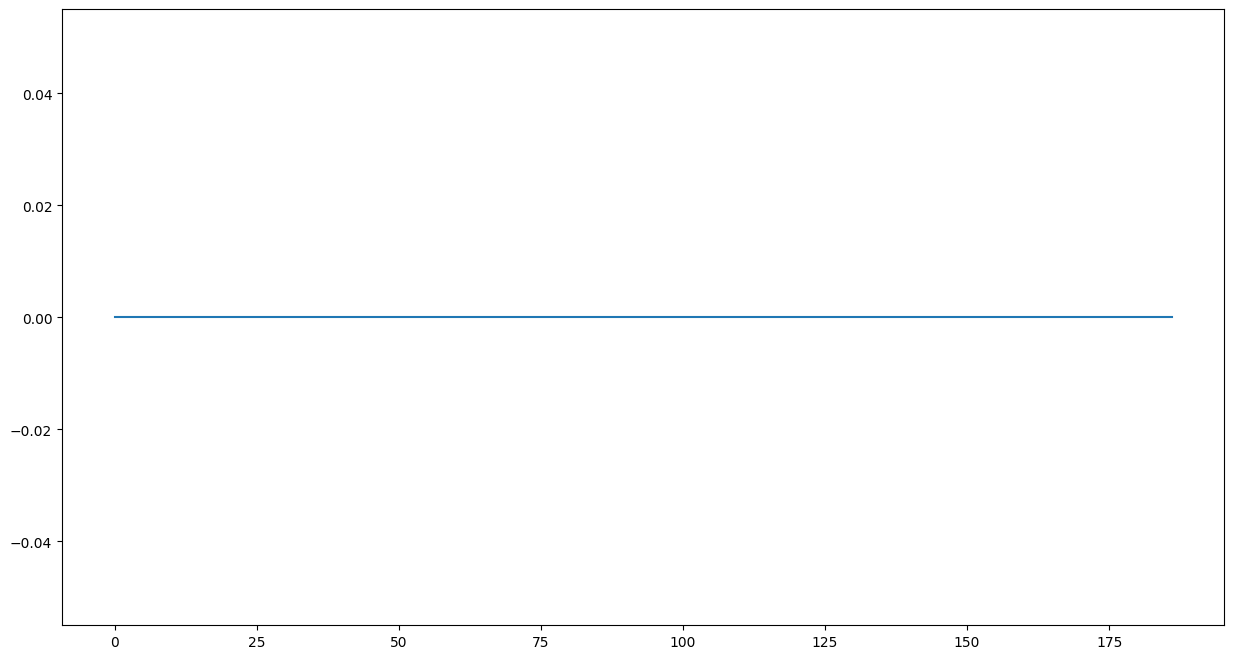

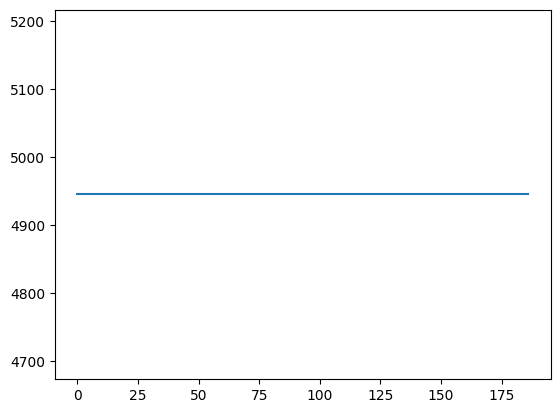

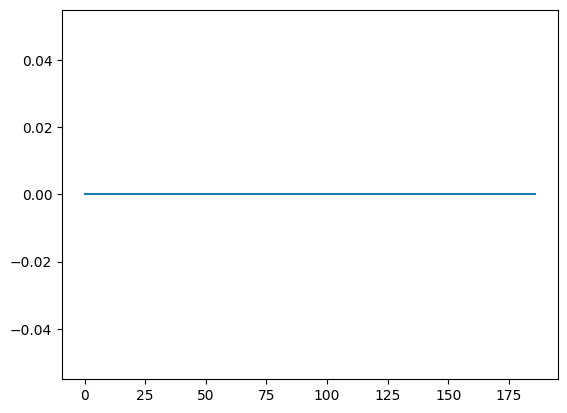

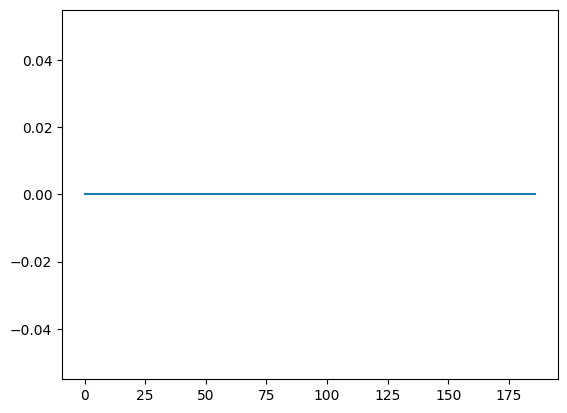

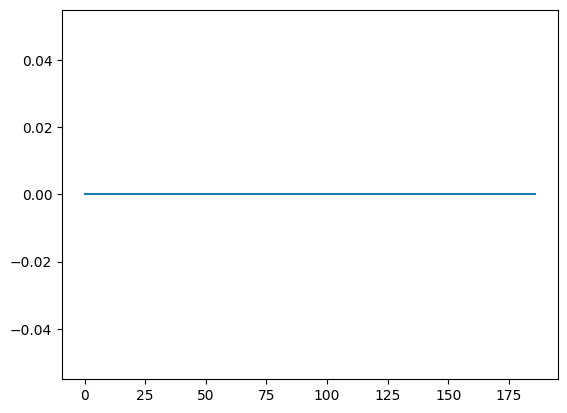

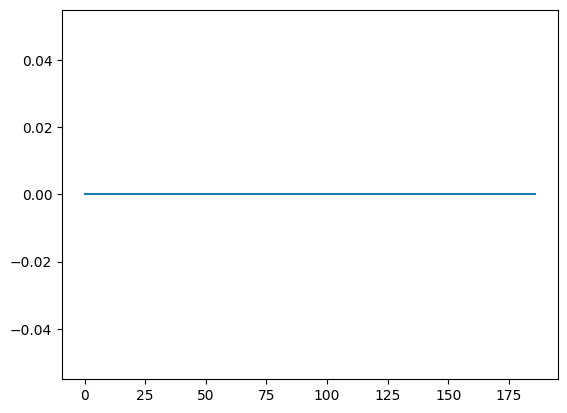

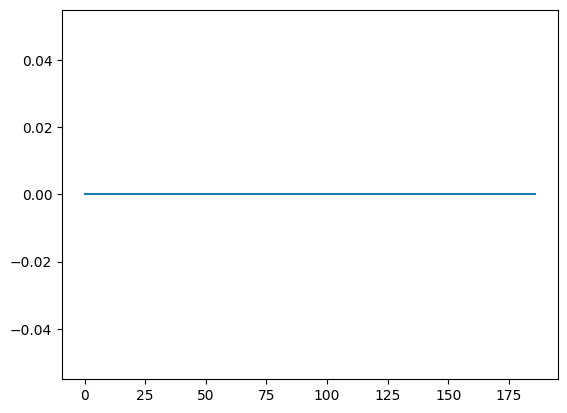

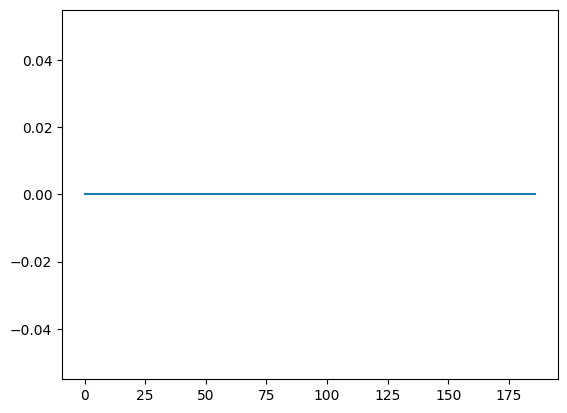

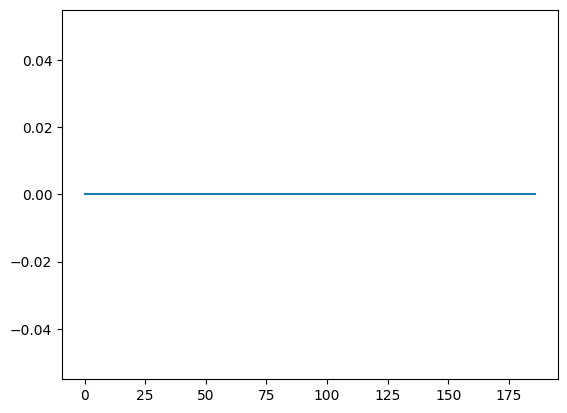

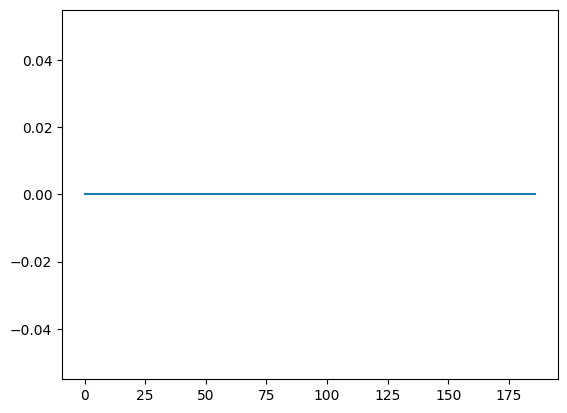

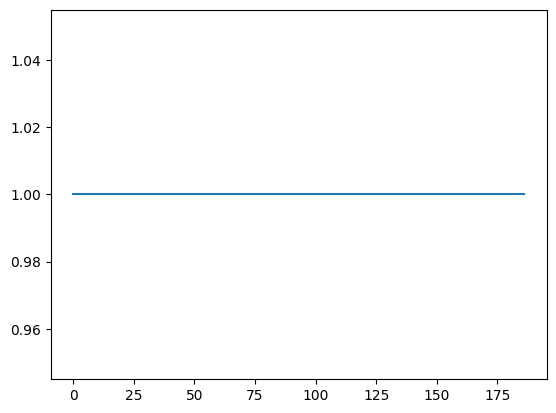

In [ ]:
plt.figure(figsize=(15, 8))
for i in constant_cols:
   plt.plot(df.index,df[i])
   plt.show()


['min_F2', 'max_F5', 'min_C1', 'min_C2']


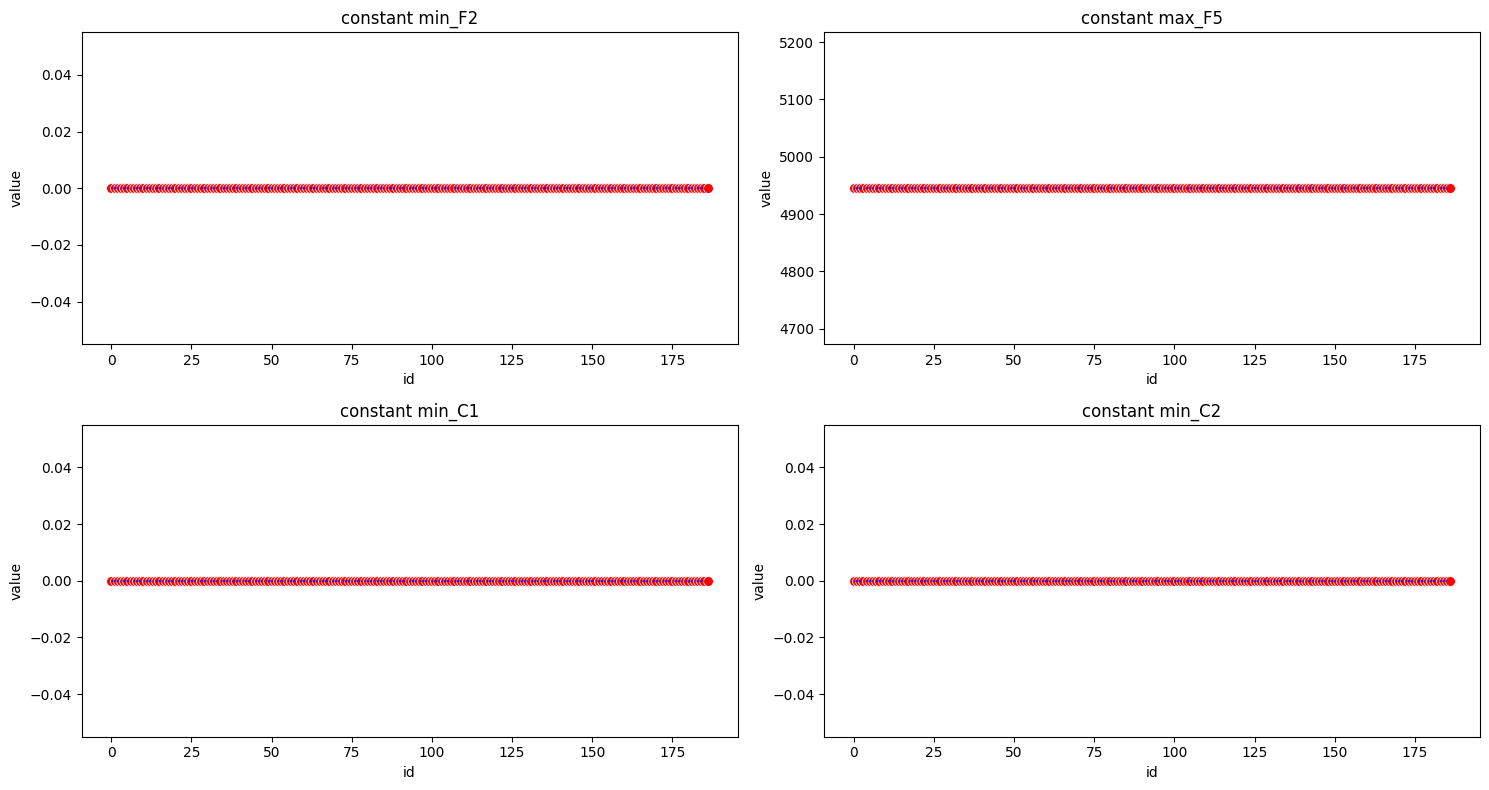

In [ ]:
cols_to_plot = constant_cols[:4]
print(cols_to_plot)
plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_plot):
        plt.subplot(2, 2, i+1)
        sns.scatterplot(x=df.index, y=df[col], color='red', s=50)
        plt.plot(df.index, df[col], color='blue', linestyle='--', alpha=0.5)

        plt.title(f'constant {col}', fontsize=12)
        plt.xlabel('id')
        plt.ylabel('value')

plt.tight_layout()
plt.show()

In [ ]:
df=df.drop(columns=constant_cols)
constant_cols


['min_F2',
 'max_F5',
 'min_C1',
 'min_C2',
 'min_C3',
 'min_C4',
 'min_C6',
 'min_C7',
 'min_C9',
 'min_C10',
 'max_C2']

In [ ]:
clean_audio_path="/content/drive/MyDrive/clean_audio.csv"
df.to_csv(clean_audio_path,index=False)

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/clean_audio.csv")
df

,participant_id,mean_F2,mean_F3,mean_F4,mean_F1,mean_F5,std_F2,std_F3,std_F4,std_F1,...,max_C3,max_C4,max_C5,max_C6,max_C7,max_C8,max_C9,max_C10,PHQ8_Binary,PHQ8_Score
0,309,739.075368,1671.167158,2567.846079,3480.773169,4390.027375,339.115097,413.701449,436.142659,428.213394,...,0.27471,0.77566,31.193,2.8044,0.46408,0.181570,2.4966,0.95818,1,15
1,310,736.930959,1648.095886,2547.954467,3437.264299,4345.283600,343.977870,411.592938,443.250967,428.811241,...,0.31072,0.76973,32.946,2.8581,0.19694,0.031303,2.4966,0.98244,0,4
2,311,703.738790,1594.150166,2549.624056,3455.444595,4360.573489,293.397543,399.443539,470.953232,437.701772,...,0.43069,0.79639,44.133,2.9581,0.30472,0.111130,2.4966,0.95462,1,21
3,314,613.694928,1534.591937,2512.325489,3432.376373,4287.512793,281.525550,437.070616,512.280886,490.228466,...,0.41537,0.82635,41.514,4.2381,0.49086,0.154900,2.4966,0.96849,0,1
4,317,649.900568,1612.827191,2558.458394,3440.888582,4356.042790,295.552570,436.172879,440.187633,426.905816,...,0.29052,15.60800,33.399,1.6912,0.22083,0.083494,2.4966,0.96850,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,477,618.574610,1623.234591,2537.316345,3433.669863,4277.396042,245.220344,461.856642,534.339927,592.162058,...,0.31196,0.87387,40.055,3.7455,0.53424,0.223170,2.4966,0.95861,0,2
183,478,651.978145,1600.880507,2508.234997,3402.581441,4274.872652,260.063942,465.389161,577.547897,626.973262,...,0.31385,0.79758,40.545,2.5528,0.40000,0.143000,2.4966,0.95053,0,1
184,481,587.064456,1577.663538,2510.728350,3467.881027,4348.275731,278.394288,413.381024,444.910677,483.011653,...,0.30565,0.84896,39.244,4.2538,0.26050,0.175970,2.4966,0.97350,0,7
185,488,641.140474,1576.898262,2511.374985,3413.405511,4332.146512,276.821675,467.036653,516.944124,515.988175,...,0.29658,0.76454,44.762,2.3233,0.28143,0.150470,2.4966,0.94856,0,0
